<a href="https://colab.research.google.com/github/Thanatipz/BSC_DPDM23/blob/main/Modelproject_now.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Missing values before Normalization:
 TMAX            0
TMIN            0
SRAD            0
lai1            0
lai2            0
lai3            0
lai4            0
lai all         0
SPI Rain1       0
SPI Rain2       0
SPI Rain3       0
SPI Rain4       0
SPI Rain all    0
dtype: int64
Infinite values before Normalization:
 TMAX            0
TMIN            0
SRAD            0
lai1            0
lai2            0
lai3            0
lai4            0
lai all         0
SPI Rain1       0
SPI Rain2       0
SPI Rain3       0
SPI Rain4       0
SPI Rain all    0
dtype: int64
Removed constant columns: ['TMAX', 'TMIN', 'SRAD']
Missing values after Normalization:
 lai1            0
lai2            0
lai3            0
lai4            0
lai all         0
SPI Rain1       0
SPI Rain2       0
SPI Rain3       0
SPI Rain4       0
SPI Rain all    0
dtype: int64

Sample Normalized 

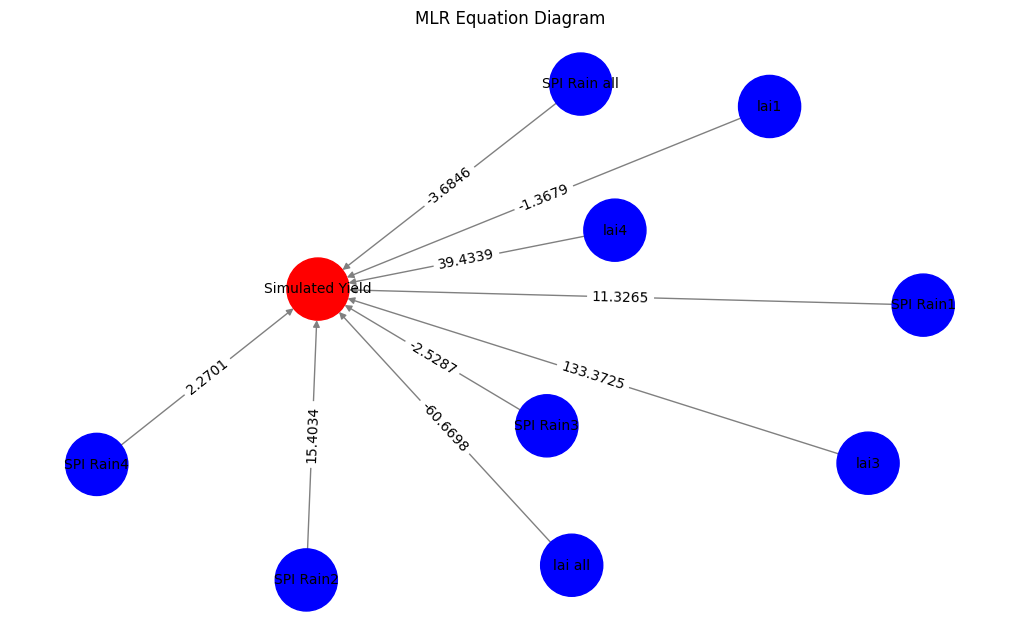

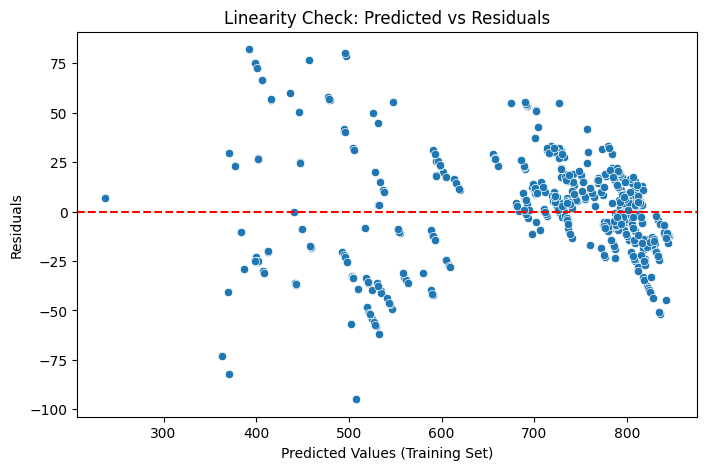


Durbin-Watson Statistic: 1.9193005681737925

Breusch-Pagan Test: p-value = 6.426520755336928e-35

MLR with Robust Standard Errors:
                             OLS Regression Results                            
Dep. Variable:        simulated yield   R-squared:                       0.962
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     799.0
Date:                Thu, 03 Apr 2025   Prob (F-statistic):          2.41e-286
Time:                        19:15:19   Log-Likelihood:                -2339.5
No. Observations:                 500   AIC:                             4699.
Df Residuals:                     490   BIC:                             4741.
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                   coef    std err          t      P>|t|      [0.025      0.9

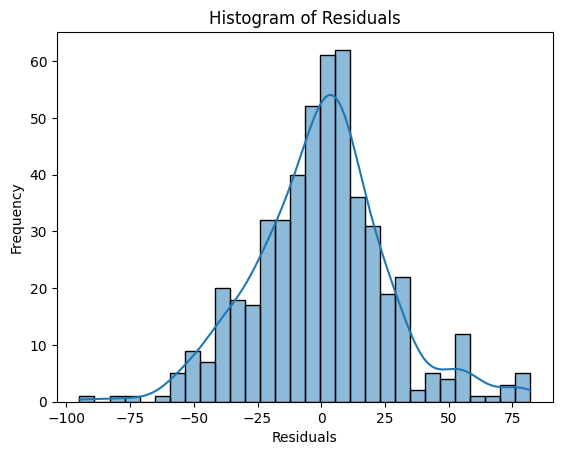

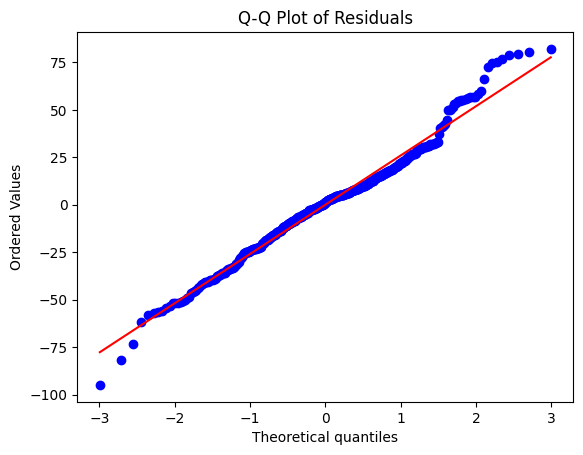


MAPE for MLR: 3.48%

MAPE for Random Forest: 1.01%

 Model Performance Metrics 
 Multiple Linear Regression (MLR)
   - MSE: 824.5624
   - RMSE: 28.7152
   - MAE: 20.9867
   - MAPE: 3.48%

 Random Forest Regression
   - MSE: 220.7195
   - RMSE: 14.8566
   - MAE: 4.4887
   - MAPE: 1.01%


In [18]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import networkx as nx
import scipy.stats as stats

# เชื่อมต่อ Google Drive
drive.mount('/content/drive')

# โหลดข้อมูล
file_path = "/content/drive/MyDrive/project 68/test625_model.xlsx"
df = pd.read_excel(file_path, sheet_name='Sheet1')

# แปลงข้อมูลเป็นตัวเลข (ลบคอลัมน์ข้อความที่ไม่จำเป็น)
df = df.drop(columns=['senario', 'stage1', 'stage2', 'stage3', 'stage4'])

# แยก features และ target
X = df.drop(columns=['simulated yield'])
y = df['simulated yield']

# แบ่งชุดข้อมูล train/test ก่อนทำ Normalization
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ตรวจสอบค่า NaN และ Inf ก่อนทำ Normalization
print("Missing values before Normalization:\n", X_train.isnull().sum())
print("Infinite values before Normalization:\n", np.isinf(X_train).sum())

# แทนที่ค่า NaN ด้วยค่ามัธยฐานของแต่ละคอลัมน์
X_train.fillna(X_train.median(), inplace=True)
X_test.fillna(X_test.median(), inplace=True)

# กำจัดคอลัมน์ที่มีค่าคงที่ทั้งหมด
constant_columns = [col for col in X_train.columns if X_train[col].nunique() == 1]
X_train.drop(columns=constant_columns, inplace=True)
X_test.drop(columns=constant_columns, inplace=True)
print("Removed constant columns:", constant_columns)

# ทำ Normalization โดยใช้ StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# แปลงกลับเป็น DataFrame โดยใช้ selected_features แทน X.columns
selected_features = X_train.columns
X_train = pd.DataFrame(X_train_scaled, columns=selected_features)
X_test = pd.DataFrame(X_test_scaled, columns=selected_features)

# ตรวจสอบค่า NaN หลังทำ Normalization
print("Missing values after Normalization:\n", X_train.isnull().sum())

# แสดงตัวอย่างข้อมูลหลังทำ Normalization
print("\nSample Normalized Data:")
print(X_train.head())

# ตรวจสอบ Multicollinearity (VIF)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
print("\nVariance Inflation Factor (VIF):\n", vif_data)

# กรองเฉพาะตัวแปรที่มี VIF < 10
selected_features = vif_data.loc[vif_data["VIF"] < 10, "Feature"].values
X_train_filtered = X_train[selected_features]
X_test_filtered = X_test[selected_features]

# Fit MLR เพื่อตรวจสอบสมมติฐาน
mlr = LinearRegression()
mlr.fit(X_train_filtered, y_train)
y_pred_mlr_train = mlr.predict(X_train_filtered)  # คำนวณ y_pred สำหรับชุดฝึกอบรม
y_pred_mlr_test = mlr.predict(X_test_filtered)    # คำนวณ y_pred สำหรับชุดทดสอบ

# คำนวณ residuals สำหรับชุดฝึกอบรม
residuals = y_train - y_pred_mlr_train

# แสดงสมการของ MLR
coefficients = mlr.coef_
intercept = mlr.intercept_
mlr_equation = "Simulated Yield = {:.4f} + ".format(intercept) + " + ".join(["({:.4f} * {})".format(coef, feature) for coef, feature in zip(coefficients, selected_features)])
print("\nMLR Equation:\n", mlr_equation)

# สร้างแผนภาพสมการ
G = nx.DiGraph()
G.add_node("Simulated Yield", color='red')
for coef, feature in zip(coefficients, selected_features):
    G.add_node(feature, color='blue')
    G.add_edge(feature, "Simulated Yield", label="{:.4f}".format(coef))

plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color=['red' if n == "Simulated Yield" else 'blue' for n in G.nodes], edge_color='gray', node_size=2000, font_size=10)
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title("MLR Equation Diagram")
plt.show()

# ตรวจสอบ Linearity (Residual Plot)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_mlr_train, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values (Training Set)")
plt.ylabel("Residuals")
plt.title("Linearity Check: Predicted vs Residuals")
plt.show()

# ตรวจสอบ Independence (Durbin-Watson Test)
dw_value = durbin_watson(residuals)
print(f"\nDurbin-Watson Statistic: {dw_value}")

# ตรวจสอบ Homoscedasticity (Breusch-Pagan Test)
X_train_const = sm.add_constant(X_train_filtered)
bp_test = het_breuschpagan(residuals, X_train_const)
print(f"\nBreusch-Pagan Test: p-value = {bp_test[1]}")

# รีเซ็ตดัชนีของ y_train และ X_train_const
y_train_reset = y_train.reset_index(drop=True)
X_train_const_reset = X_train_const.reset_index(drop=True)

# ใช้ OLS ในการคำนวณค่าพารามิเตอร์ของ MLR
model = sm.OLS(y_train_reset, X_train_const_reset).fit()  # สร้างโมเดล OLS
robust_model = model.get_robustcov_results(cov_type='HC3')  # ใช้ HC3 สำหรับ robust standard errors
print("\nMLR with Robust Standard Errors:\n", robust_model.summary())

# ตรวจสอบ Normality ของ Residuals (Histogram และ Q-Q Plot)
sns.histplot(residuals, kde=True, bins=30)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# ฟังก์ชันคำนวณ MAPE
def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# คำนวณ MAPE สำหรับ MLR
mape_mlr = calculate_mape(y_test, y_pred_mlr_test)
print(f"\nMAPE for MLR: {mape_mlr:.2f}%")

# สร้างและทดสอบโมเดล Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_filtered, y_train)
y_pred_rf = rf.predict(X_test_filtered)

# คำนวณ MSE, RMSE, และ MAE สำหรับ MLR
mse_mlr = mean_squared_error(y_test, y_pred_mlr_test)
rmse_mlr = np.sqrt(mse_mlr)
mae_mlr = mean_absolute_error(y_test, y_pred_mlr_test)

# คำนวณ MSE, RMSE, และ MAE สำหรับ Random Forest
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

# คำนวณ MAPE สำหรับ Random Forest
mape_rf = calculate_mape(y_test, y_pred_rf)
print(f"\nMAPE for Random Forest: {mape_rf:.2f}%")

# แสดงผลลัพธ์
print("\n Model Performance Metrics ")
print(" Multiple Linear Regression (MLR)")
print(f"   - MSE: {mse_mlr:.4f}")
print(f"   - RMSE: {rmse_mlr:.4f}")
print(f"   - MAE: {mae_mlr:.4f}")
print(f"   - MAPE: {mape_mlr:.2f}%")

print("\n Random Forest Regression")
print(f"   - MSE: {mse_rf:.4f}")
print(f"   - RMSE: {rmse_rf:.4f}")
print(f"   - MAE: {mae_rf:.4f}")
print(f"   - MAPE: {mape_rf:.2f}%")




Summary of Hypothesis Tests:
1. Linearity: ตรวจสอบจาก Residual Plot
2. Independence (Durbin-Watson Test): Durbin-Watson Statistic = 1.9193005681737925
3. Homoscedasticity (Breusch-Pagan Test): p-value = 6.426520755336928e-35
   - p-value < 0.05: อาจมีปัญหาความแปรปรวนไม่สม่ำเสมอ (Heteroscedasticity)
4. Normality of Residuals: ตรวจสอบจาก Histogram และ Q-Q Plot

Important Features (Linear Regression):
        Feature  Coefficient
1          lai3   133.372534
2          lai4    39.433868
5     SPI Rain2    15.403375
4     SPI Rain1    11.326511
7     SPI Rain4     2.270064
0          lai1    -1.367852
6     SPI Rain3    -2.528684
8  SPI Rain all    -3.684588
3       lai all   -60.669793

Important Features (Random Forest):
        Feature  Importance
1          lai3    0.890480
5     SPI Rain2    0.043825
2          lai4    0.029490
3       lai all    0.009177
6     SPI Rain3    0.008096
8  SPI Rain all    0.006630
0          lai1    0.005994
4     SPI Rain1    0.005887
7     SPI Rain4   

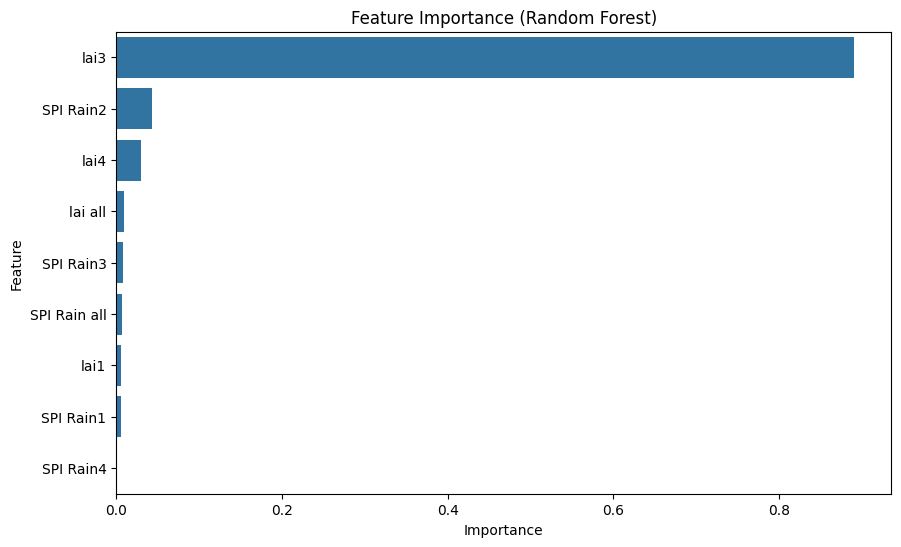

In [19]:
# สรุปผลทดสอบสมมติฐาน
print("\nSummary of Hypothesis Tests:")
print(f"1. Linearity: ตรวจสอบจาก Residual Plot")
print(f"2. Independence (Durbin-Watson Test): Durbin-Watson Statistic = {dw_value}")
print(f"3. Homoscedasticity (Breusch-Pagan Test): p-value = {bp_test[1]}")
if bp_test[1] > 0.05:
    print("   - p-value > 0.05: ไม่มีปัญหาความแปรปรวนไม่สม่ำเสมอ (Homoscedasticity) ")
else:
    print("   - p-value < 0.05: อาจมีปัญหาความแปรปรวนไม่สม่ำเสมอ (Heteroscedasticity)")
print(f"4. Normality of Residuals: ตรวจสอบจาก Histogram และ Q-Q Plot")

# เพิ่มการแสดงฟีเจอร์ที่สำคัญจาก MLR
print("\nImportant Features (Linear Regression):")
feature_importance_mlr = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': mlr.coef_
})
# เรียงลำดับฟีเจอร์จากการคำนวณ Coefficients (ค่าพารามิเตอร์ใน Linear Regression)
feature_importance_mlr = feature_importance_mlr.sort_values(by='Coefficient', ascending=False)
print(feature_importance_mlr)

# เพิ่มการแสดงฟีเจอร์ที่สำคัญจาก Random Forest
print("\nImportant Features (Random Forest):")
# คำนวณ feature importance จาก Random Forest
feature_importance_rf = pd.DataFrame({
    'Feature': selected_features,
    'Importance': rf.feature_importances_
})
# เรียงลำดับฟีเจอร์จากการคำนวณ Feature Importance
feature_importance_rf = feature_importance_rf.sort_values(by='Importance', ascending=False)
print(feature_importance_rf)

# แสดงแผนภาพฟีเจอร์ที่สำคัญ (สำหรับ Random Forest)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_rf)
plt.title("Feature Importance (Random Forest)")
plt.show()


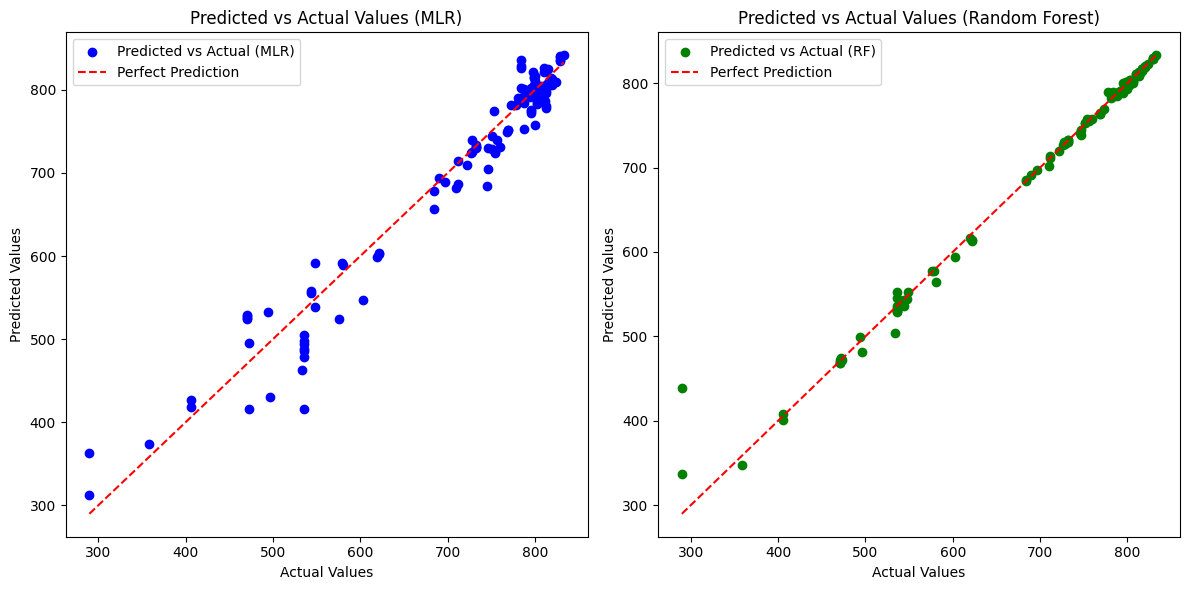

In [20]:
# ทำนายค่าจากโมเดล MLR
y_pred_mlr_test = mlr.predict(X_test_filtered)

# ทำนายค่าจากโมเดล Random Forest
y_pred_rf = rf.predict(X_test_filtered)

# สร้างกราฟ Scatter Plot สำหรับค่าทำนายและค่าจริงของ MLR
plt.figure(figsize=(12, 6))

# Subplot สำหรับ MLR
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_mlr_test, color='blue', label='Predicted vs Actual (MLR)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Values (MLR)')
plt.legend()

# Subplot สำหรับ Random Forest
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_rf, color='green', label='Predicted vs Actual (RF)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Values (Random Forest)')
plt.legend()

plt.tight_layout()
plt.show()
